# Imports — Improved Sepsis pipeline (sqrt-tempered class-weighted CE on `concept:name`)

Single intervention active in this run:

- Variant-balanced oversampling (`VARIANT_TEMPERATURE = 0.0`) — disabled
- Shortcut-feature masking (`FEATURE_MASK_PROB = 0.0`) — disabled
- Class-weighted CE on `concept:name` — **ENABLED** (`CE_TEMPERATURE = 0.5`, sqrt-tempered inverse frequency, mean-normalised over the 17 active classes; padding masked)
- Teacher forcing (`teacher_forcing_ratio = 0.8`, baseline value)

Saving to `Sepsis_full_grad_norm_new_4layer_weighted_ce.pkl`.

In [1]:
import importlib
import sys
import torch
from pathlib import Path

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir() and (_current / 'data').is_dir():
        break
    _current = _current.parent
_project_root = _current

# Add upstream src/ paths AND the local improved/lib so `import losses_weighted` /
# `import trainer_weighted` resolve to the forked copies in this folder.
_lib_dir = _project_root / 'src/interpretability/improved_pipeline/henryk/sepsis/improved/lib'
for p in [_project_root, _project_root / 'src', _lib_dir]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))


# Data

### Load Data Files

In [2]:
# Path to your pickle file (saved with torch.save)
file_path_train = '../../old/Loader/Sepsis_all_5_train.pkl'
# Load the dataset using torch.load
sepsis_train_dataset = torch.load(file_path_train, weights_only=False)
# Check the type of the loaded dataset
print(type(sepsis_train_dataset))  # Should output something like <class 'torch.utils.data.dataset.TensorDataset'>

# Path to your pickle file (saved with torch.save)
file_path_val = '../../old/Loader/Sepsis_all_5_val.pkl'
# Load the dataset using torch.load
sepsis_val_dataset = torch.load(file_path_val, weights_only=False)
# Check the type of the loaded dataset
print(type(sepsis_val_dataset))  # Should output something like <class 'torch.utils.data.dataset.TensorDataset'>

<class 'event_log_loader.new_event_log_loader.EventLogDataset'>
<class 'event_log_loader.new_event_log_loader.EventLogDataset'>


### Train Data Insights

In [3]:
# BPIC 17 Dataset Categories, Features:

sepsis_all_categories = sepsis_train_dataset.all_categories

sepsis_all_categories_cat = sepsis_all_categories[0]
print(sepsis_all_categories_cat)

sepsis_all_categories_num = sepsis_all_categories[1]
print(sepsis_all_categories_num)

for i, cat in enumerate(sepsis_all_categories_cat):
     print(f"Sepsis (5) Categorical feature: {cat[0]}, Index position in categorical data list: {i}")
     print(f"Sepsis (5) Total Amount of Category labels: {cat[1]}")
print('\n')    
for i, num in enumerate(sepsis_all_categories_num):
     print(f"Sepsis (5) Numerical feature: {num[0]}, Index position in categorical data list: {i}")
     print(f"Sepsis (5) Amount Category Lables: {num[1]}")

[('concept:name', 18, {'Admission IC': 1, 'Admission NC': 2, 'CRP': 3, 'EOS': 4, 'ER Registration': 5, 'ER Sepsis Triage': 6, 'ER Triage': 7, 'IV Antibiotics': 8, 'IV Liquid': 9, 'LacticAcid': 10, 'Leucocytes': 11, 'Release A': 12, 'Release B': 13, 'Release C': 14, 'Release D': 15, 'Release E': 16, 'Return ER': 17}), ('InfectionSuspected', 5, {'EOS': 1, 'False': 2, 'True': 3, nan: 4}), ('org:group', 27, {'?': 1, 'A': 2, 'B': 3, 'C': 4, 'D': 5, 'E': 6, 'EOS': 7, 'F': 8, 'G': 9, 'H': 10, 'I': 11, 'J': 12, 'K': 13, 'L': 14, 'M': 15, 'N': 16, 'O': 17, 'P': 18, 'Q': 19, 'R': 20, 'S': 21, 'T': 22, 'U': 23, 'V': 24, 'W': 25, 'X': 26}), ('DiagnosticBlood', 5, {'EOS': 1, 'False': 2, 'True': 3, nan: 4}), ('DisfuncOrg', 5, {'EOS': 1, 'False': 2, 'True': 3, nan: 4}), ('SIRSCritTachypnea', 5, {'EOS': 1, 'False': 2, 'True': 3, nan: 4}), ('Hypotensie', 5, {'EOS': 1, 'False': 2, 'True': 3, nan: 4}), ('SIRSCritHeartRate', 5, {'EOS': 1, 'False': 2, 'True': 3, nan: 4}), ('Infusion', 5, {'EOS': 1, 'False'

### Input Features for Encoder and Decoder

In [4]:
# Create lists with name of Encoder features (input) and decoder features (input & output)

# Encoder features:
enc_feat_cat = []
enc_feat_num = []
for cat in sepsis_all_categories_cat:
    enc_feat_cat.append(cat[0])
for num in sepsis_all_categories_num:
    enc_feat_num.append(num[0])
enc_feat = [enc_feat_cat, enc_feat_num]
print("Input features encoder: ", enc_feat)

"""
# Decoder features:
dec_feat_cat = enc_feat_cat
dec_feat_num = enc_feat_num
dec_feat = [dec_feat_cat, dec_feat_num]
print("Features decoder: ", dec_feat)
"""

# Decoder features:
dec_feat_cat = ['concept:name', 'org:group', 'lifecycle:transition']
dec_feat_num = ['case_elapsed_time', 'event_elapsed_time']
dec_feat = [dec_feat_cat, dec_feat_num]
print("Features decoder: ", dec_feat)

Input features encoder:  [['concept:name', 'InfectionSuspected', 'org:group', 'DiagnosticBlood', 'DisfuncOrg', 'SIRSCritTachypnea', 'Hypotensie', 'SIRSCritHeartRate', 'Infusion', 'DiagnosticArtAstrup', 'DiagnosticIC', 'DiagnosticSputum', 'DiagnosticLiquor', 'DiagnosticOther', 'SIRSCriteria2OrMore', 'DiagnosticXthorax', 'SIRSCritTemperature', 'DiagnosticUrinaryCulture', 'SIRSCritLeucos', 'Oligurie', 'DiagnosticLacticAcid', 'lifecycle:transition', 'Diagnose', 'Hypoxie', 'DiagnosticUrinarySediment', 'DiagnosticECG'], ['case_elapsed_time', 'event_elapsed_time', 'day_in_week', 'seconds_in_day', 'Age', 'Leucocytes', 'CRP', 'LacticAcid']]
Features decoder:  [['concept:name', 'org:group', 'lifecycle:transition'], ['case_elapsed_time', 'event_elapsed_time']]


# Variant-balanced training-set oversampling

Helpdesk-style §1b analogue for Sepsis. Each unique case has a *variant* = its full sequence of activities. This cell oversamples training cases by **inverse variant frequency** (tempered) so the gradient steps spend more time on rare variants per epoch.

Implemented via case-level window duplication (`ConcatDataset` + `Subset`), so the trainer's internal `DataLoader(shuffle=True)` doesn't need to be replaced with a `WeightedRandomSampler`. The expected effect of the two implementations is the same.

**Sepsis caveat:** the train log is variant-diverse — most variants are singletons. Quantile-based targets degenerate (target lands at 1, no oversampling), so this cell uses an **absolute min-count target** instead. Inspect the printed variant-count histogram before tuning.

Knobs at the top of the cell:

- `VARIANT_TEMPERATURE` (default `0.5`) — exponent on inverse frequency. `0.0` disables.
- `VARIANT_MIN_COUNT_TARGET` (default `5`) — variants seen at least this often get no extra copies; rarer variants are pulled toward this count.
- `VARIANT_MAX_FACTOR` (default `8`) — cap on extra copies any variant can receive.

In [5]:
from collections import Counter
from torch.utils.data import ConcatDataset, Subset
import numpy as np

# --- Knobs -------------------------------------------------------------------
# (DISABLED — Sepsis variant distribution is ~93% singletons so this technique
#  degenerates to "just train longer". Set VARIANT_TEMPERATURE > 0 to re-enable.)
VARIANT_TEMPERATURE = 0.0      # 0.0 disables; 1.0 = full inverse-frequency; 0.5 = sqrt-tempered
VARIANT_MIN_COUNT_TARGET = 5   # variants with count >= this get 0 extra copies
VARIANT_MAX_FACTOR = 8         # cap on extra copies per variant
# -----------------------------------------------------------------------------

ACTIVITY_CAT_INDEX = 0
case_ids_per_window = sepsis_train_dataset.tensor_list[2]
if not isinstance(case_ids_per_window, list):
    case_ids_per_window = list(case_ids_per_window)
activity_t = sepsis_train_dataset.tensor_list[0][ACTIVITY_CAT_INDEX]   # [N, W]

# Recover the full activity sequence for each unique case by picking the LONGEST window per case_id.
case_to_best_idx = {}
case_to_best_len = {}
for idx in range(activity_t.shape[0]):
    cid = case_ids_per_window[idx]
    rc = int((activity_t[idx] != 0).sum().item())
    if rc > case_to_best_len.get(cid, -1):
        case_to_best_len[cid] = rc
        case_to_best_idx[cid] = idx

case_to_variant = {cid: tuple(a for a in activity_t[idx].tolist() if a != 0)
                    for cid, idx in case_to_best_idx.items()}
variant_counts = Counter(case_to_variant.values())

n_cases = len(case_to_variant)
n_variants = len(variant_counts)
print(f'Train cases: {n_cases}, distinct variants: {n_variants}')

# Histogram of variant counts -- tells you whether this technique can do anything.
count_hist = Counter(variant_counts.values())
print('Variant-count histogram (bucket -> #variants):')
for k in sorted(count_hist.keys())[:8]:
    print(f'  count={k:3d}: {count_hist[k]:4d} variants ({100*count_hist[k]/n_variants:.1f}%)')
if max(count_hist) > 8:
    rest = sum(v for k, v in count_hist.items() if k > 8)
    print(f'  count>8 : {rest:4d} variants ({100*rest/n_variants:.1f}%)')
print(f'Singleton variants (count=1): {count_hist.get(1, 0)} ({100*count_hist.get(1,0)/n_variants:.1f}%)')

if VARIANT_TEMPERATURE <= 0.0:
    print('\n§1b-variant disabled (VARIANT_TEMPERATURE = 0).')
else:
    target = float(VARIANT_MIN_COUNT_TARGET)
    print(f'\nMin-count target per variant: {target:.0f}')

    # extra_copies(variant) = round( (target / count)^TEMP - 1 ), clipped to [0, MAX_FACTOR]
    variant_extra = {}
    for v, c in variant_counts.items():
        ratio = max(target / c, 1.0)
        extra = ratio ** VARIANT_TEMPERATURE - 1.0
        variant_extra[v] = int(round(min(extra, VARIANT_MAX_FACTOR)))

    extra_per_case = [variant_extra[case_to_variant[cid]] for cid in case_to_variant]
    print(f'Extra-copies per case histogram: {dict(Counter(extra_per_case).most_common())}')

    extra_window_indices = []
    for widx in range(activity_t.shape[0]):
        cid = case_ids_per_window[widx]
        n_extra = variant_extra[case_to_variant[cid]]
        if n_extra > 0:
            extra_window_indices.extend([widx] * n_extra)

    base_n = len(sepsis_train_dataset)
    if extra_window_indices:
        _base = sepsis_train_dataset
        sepsis_train_dataset = ConcatDataset([_base, Subset(_base, extra_window_indices)])
        sepsis_train_dataset.all_categories = _base.all_categories  # downstream cells expect this
        added = len(extra_window_indices)
        print(f'\nVariant-balanced oversample applied: '
              f'+{added} windows ({100*added/base_n:+.1f}%), new total {len(sepsis_train_dataset)}.')
    else:
        print('\nNo variants needed extra copies (all already at-or-above target).')

Train cases: 683, distinct variants: 577
Variant-count histogram (bucket -> #variants):
  count=  1:  535 variants (92.7%)
  count=  2:   28 variants (4.9%)
  count=  3:    8 variants (1.4%)
  count=  5:    1 variants (0.2%)
  count=  7:    1 variants (0.2%)
  count= 10:    1 variants (0.2%)
  count= 12:    1 variants (0.2%)
  count= 13:    1 variants (0.2%)
  count>8 :    4 variants (0.7%)
Singleton variants (count=1): 535 (92.7%)

§1b-variant disabled (VARIANT_TEMPERATURE = 0).


# Shortcut-feature masking during training

Targeted intervention based on the IG attribution analysis: the model's activity-head attribution is dominated by `lifecycle:transition`, `org:group`, and `concept:name` while medical features get almost zero. This cell wraps the train dataset to randomly **zero the side-channel categorical features** (`org:group`, `lifecycle:transition`) at each draw — independent dice rolls per feature, probability `FEATURE_MASK_PROB = 0.5`. **Tier 1 default**: `concept:name` is intentionally NOT in the mask list because it's the activity prefix the model conditions on; masking it conflates with the case-end pattern and pushes the model toward a degenerate two-mode behaviour. Add it back to `MASK_FEATURES` only if Tier 1 doesn't move the needle (and prefer positional masking in that case).

**Diagnostic interpretation after retraining + IG re-run:**

- Medical-feature attribution rises → shortcut hypothesis confirmed; the model *can* use medical features when shortcuts are unavailable.
- Medical-feature attribution stays at ~0 → the failure is upstream (medical features don't carry signal in their current encoding — see the earlier `Age` / case-level imputation discussion).

**Set `FEATURE_MASK_PROB = 0.0` to fully disable.**

In [6]:
import torch

# FeatureDropoutWrapper lives in `improved/lib/feature_dropout.py` (not inline in
# the notebook) so DataLoader spawn workers can pickle/unpickle it. The
# `improved/lib` directory was added to sys.path in cell 1.
import feature_dropout
import importlib
importlib.reload(feature_dropout)
from feature_dropout import FeatureDropoutWrapper


# --- Knobs ---
FEATURE_MASK_PROB = 0.0  # DISABLED (was 0.5 — Tier 1 shortcut masking)
MASK_FEATURES = ['org:group', 'lifecycle:transition']  # Tier 1: side-channel shortcuts only — keep concept:name (the activity prefix) unmasked

if FEATURE_MASK_PROB > 0 and MASK_FEATURES:
    name_to_cat_idx = {c[0]: i for i, c in enumerate(sepsis_train_dataset.all_categories[0])}
    mask_idx = [name_to_cat_idx[n] for n in MASK_FEATURES if n in name_to_cat_idx]
    missing = [n for n in MASK_FEATURES if n not in name_to_cat_idx]
    if missing:
        print(f'WARNING: features not found in dataset and skipped: {missing}')

    if mask_idx:
        sepsis_train_dataset = FeatureDropoutWrapper(
            sepsis_train_dataset, mask_idx, FEATURE_MASK_PROB,
        )
        resolved = [(name_to_cat_idx[n], n) for n in MASK_FEATURES if n in name_to_cat_idx]
        print(f'FeatureDropoutWrapper active: p={FEATURE_MASK_PROB} per feature, '
              f'masking {resolved}')

        # Sanity check: 20 draws on the same index — average non-zero presence
        # per masked feature should be ~ (1 - mask_prob).
        from collections import Counter
        present_counts = Counter()
        N_PROBE = 20
        for _ in range(N_PROBE):
            c, _, _ = sepsis_train_dataset[0]
            for ci, name in resolved:
                if (c[ci] != 0).any().item():
                    present_counts[name] += 1
        print(f'Sanity ({N_PROBE} draws of idx 0) — feature present rate '
              f'(expected ~{1-FEATURE_MASK_PROB:.2f}):')
        for ci, name in resolved:
            print(f'  {name:25s} present {present_counts[name]}/{N_PROBE} = '
                  f'{100*present_counts[name]/N_PROBE:.0f}%')
    else:
        print('FeatureDropoutWrapper not applied: no listed feature exists in this dataset.')
else:
    print('FeatureDropoutWrapper disabled (FEATURE_MASK_PROB = 0 or empty MASK_FEATURES).')

FeatureDropoutWrapper disabled (FEATURE_MASK_PROB = 0 or empty MASK_FEATURES).


# Model

In [7]:
import model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model
importlib.reload(model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model)
from model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM

# Prediction decoder output sequence length
seq_len_pred = 4 

# Size hidden layer
hidden_size = 64 # prev 128

# Number of cells
num_layers = 2 # prev: 4

# Fixed Dropout probability 
dropout = 0.1

# Encoder Decoder model initialization
model = DropoutUncertaintyEncoderDecoderLSTM(data_set_categories=sepsis_all_categories,
                                             enc_feat=enc_feat,
                                             dec_feat=dec_feat,
                                             seq_len_pred=seq_len_pred,
                                             hidden_size=hidden_size,
                                             num_layers=num_layers,
                                             dropout=dropout)

Data set categories:  ([('concept:name', 18, {'Admission IC': 1, 'Admission NC': 2, 'CRP': 3, 'EOS': 4, 'ER Registration': 5, 'ER Sepsis Triage': 6, 'ER Triage': 7, 'IV Antibiotics': 8, 'IV Liquid': 9, 'LacticAcid': 10, 'Leucocytes': 11, 'Release A': 12, 'Release B': 13, 'Release C': 14, 'Release D': 15, 'Release E': 16, 'Return ER': 17}), ('InfectionSuspected', 5, {'EOS': 1, 'False': 2, 'True': 3, nan: 4}), ('org:group', 27, {'?': 1, 'A': 2, 'B': 3, 'C': 4, 'D': 5, 'E': 6, 'EOS': 7, 'F': 8, 'G': 9, 'H': 10, 'I': 11, 'J': 12, 'K': 13, 'L': 14, 'M': 15, 'N': 16, 'O': 17, 'P': 18, 'Q': 19, 'R': 20, 'S': 21, 'T': 22, 'U': 23, 'V': 24, 'W': 25, 'X': 26}), ('DiagnosticBlood', 5, {'EOS': 1, 'False': 2, 'True': 3, nan: 4}), ('DisfuncOrg', 5, {'EOS': 1, 'False': 2, 'True': 3, nan: 4}), ('SIRSCritTachypnea', 5, {'EOS': 1, 'False': 2, 'True': 3, nan: 4}), ('Hypotensie', 5, {'EOS': 1, 'False': 2, 'True': 3, nan: 4}), ('SIRSCritHeartRate', 5, {'EOS': 1, 'False': 2, 'True': 3, nan: 4}), ('Infusion'

# Loss Object Creation

In [8]:
# Use the forked Loss with optional per-class weighting on CE heads.
import losses_weighted
importlib.reload(losses_weighted)
from losses_weighted import Loss

loss_obj = Loss()

# Numerical features trained with log-normal loss (unchanged from old pipeline):
log_normal_loss_num_feature = ['case_elapsed_time', 'event_elapsed_time']


# Class weights for `concept:name`

Inverse-frequency weights computed on the train split only. Padding (class 0) is masked (weight=0); the remaining weights are mean-normalized to 1 so the overall scale of the activity-head loss is unchanged.


In [9]:
import numpy as np

# --- Knob ---
# Tempering exponent on inverse-frequency weights. T=1.0 is plain inverse-frequency
# (max weight ~8.0 on 20-sample class — spiky). T=0.5 is sqrt-tempered (max ~4.0,
# min ~0.16). T=0.0 disables weighting.
CE_TEMPERATURE = 0.5

# Locate concept:name index in the categorical feature list.
_cn_idx = next(i for i, _c in enumerate(sepsis_all_categories_cat)
               if _c[0] == 'concept:name')
_n_classes = sepsis_all_categories_cat[_cn_idx][1]
_suffix_split = 4  # mirrors suffix_data_split_value below

# Count target class frequencies on suffix positions of the train split.
counts = np.zeros(_n_classes, dtype=np.int64)
for _i in range(len(sepsis_train_dataset)):
    _cats, _, _ = sepsis_train_dataset[_i]
    _t = _cats[_cn_idx][-_suffix_split:].long().numpy()
    for _c in _t:
        counts[int(_c)] += 1

# Inverse-frequency (tempered), mask padding (idx 0 -> weight 0), mean-normalize
# over non-padding classes so weights average to 1 across the actual 17 classes.
_weights = np.zeros(_n_classes, dtype=np.float32)
_nonpad_counts = counts.copy()
_nonpad_counts[0] = 0
_nz = _nonpad_counts > 0
_weights[_nz] = (1.0 / _nonpad_counts[_nz]) ** CE_TEMPERATURE
_active = (np.arange(_n_classes) != 0) & _nz
if _weights[_active].mean() > 0:
    _weights[_active] = _weights[_active] / _weights[_active].mean()

if CE_TEMPERATURE > 0.0:
    cat_class_weights = {'concept:name': torch.tensor(_weights, dtype=torch.float32)}
else:
    cat_class_weights = {}

print(f'CE_TEMPERATURE = {CE_TEMPERATURE}')
print(f'concept:name class counts (train, suffix only):')
for _c in range(_n_classes):
    print(f'  class {_c:2d}: count={int(counts[_c]):6d}  weight={_weights[_c]:.4f}')
print(f'\nactive-class weight mean: {_weights[_active].mean():.4f}  '
      f'(should be ~1.0; padding idx 0 weight = {_weights[0]:.4f})')
print(f'active-class weight min/max: {_weights[_active].min():.4f} / {_weights[_active].max():.4f}')


CE_TEMPERATURE = 0.5
concept:name class counts (train, suffix only):
  class  0: count=     0  weight=0.0000
  class  1: count=   316  weight=1.0183
  class  2: count=  3102  weight=0.3250
  class  3: count=  8334  weight=0.1983
  class  4: count= 12273  weight=0.1634
  class  5: count=    62  weight=2.2989
  class  6: count=  1619  weight=0.4499
  class  7: count=   855  weight=0.6191
  class  8: count=  2150  weight=0.3904
  class  9: count=  1771  weight=0.4301
  class 10: count=  3694  weight=0.2978
  class 11: count=  8472  weight=0.1967
  class 12: count=  1724  weight=0.4360
  class 13: count=   160  weight=1.4311
  class 14: count=    80  weight=2.0238
  class 15: count=    80  weight=2.0238
  class 16: count=    20  weight=4.0477
  class 17: count=   776  weight=0.6498

active-class weight mean: 1.0000  (should be ~1.0; padding idx 0 weight = 0.0000)
active-class weight min/max: 0.1634 / 4.0477


# Training Configuration

In [10]:
import trainer_weighted
importlib.reload(trainer_weighted)
from trainer_weighted import Trainer
from torch.optim.lr_scheduler import ReduceLROnPlateau

from torch.utils.tensorboard import SummaryWriter

writer = SummaryWriter(comment="Full_Sepsis_grad")

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Start learning rate
learning_rate = 1e-4# prev: 1e-5

# Optimizer and Scheduler
# optimizer = torch.optim.Adam(params=model.parameters(), lr=learning_rate, weight_decay=0)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-9) # old: ReduceLROnPlateau(optimizer, mode='min', factor=0.01, patience=1, min_lr=1e-9)

# Epochs
num_epochs = 100

# Batch size
batch_size = 32 # prev: 128

# lambda for L2 (weight, bias, dropout) regularization: According to formula: 1/2N
# regularization_term = 1.0/(2.0*batch_size)
regularization_term =  1e-4

# shuffle data
shuffle = True

# Teacher forcing: Smaller 0.5 more predicted events are used for next event prediction.
teacher_forcing_ratio = 0.8  # BASELINE (was lowered to 0.3 in the previous intervention)

optimize_values = {"regularization_term":regularization_term,
                   "optimizer":optimizer,
                   "scheduler": scheduler,
                   "epochs":num_epochs,
                   "mini_batches":batch_size,
                   "shuffle": shuffle,
                   "teacher_forcing_ratio":teacher_forcing_ratio,}

suffix_data_split_value = 4

# GradNorm parameter
use_gradnorm = True
gn_alpha = 1.5
gn_learning_rate = 1e-4
# gn_learning_rate =  0.025

number_tasks = len(dec_feat[0]) + len(dec_feat[1])

gradNorm = {"use_gradnorm":use_gradnorm,
            "number_tasks": number_tasks,
            "gn_alpha":gn_alpha,
            "gn_learning_rate": gn_learning_rate}

trainer = Trainer(device=device,
                  model=model,
                  data_train=sepsis_train_dataset,
                  data_val=sepsis_val_dataset,
                  loss_obj=loss_obj,
                  log_normal_loss_num_feature=log_normal_loss_num_feature,
                  optimize_values=optimize_values,
                  suffix_data_split_value=suffix_data_split_value,
                  writer=writer,
                  gradnorm_values=gradNorm,
                  cat_class_weights=cat_class_weights,
                  save_model_n_th_epoch = 1,
                  saving_path = 'Sepsis_full_grad_norm_new_4layer_weighted_ce.pkl')

# Train the model:
train_attenuated_losses, val_losses, val_attenuated_losses = trainer.train_model()

Device:  cpu
Model:  DropoutUncertaintyEncoderDecoderLSTM(
  (embeddings_enc): ModuleList(
    (0): Embedding(18, 8)
    (1): Embedding(5, 4)
    (2): Embedding(27, 10)
    (3-20): 18 x Embedding(5, 4)
    (21): Embedding(3, 3)
    (22): Embedding(123, 24)
    (23-25): 3 x Embedding(5, 4)
  )
  (encoder): DropoutUncertaintyLSTMEncoder(
    (embeddings): ModuleList(
      (0): Embedding(18, 8)
      (1): Embedding(5, 4)
      (2): Embedding(27, 10)
      (3-20): 18 x Embedding(5, 4)
      (21): Embedding(3, 3)
      (22): Embedding(123, 24)
      (23-25): 3 x Embedding(5, 4)
    )
    (first_layer): DropoutUncertaintyLSTMCell(
      (Wi): Linear(in_features=141, out_features=64, bias=True)
      (Ui): Linear(in_features=64, out_features=64, bias=True)
      (Wf): Linear(in_features=141, out_features=64, bias=True)
      (Uf): Linear(in_features=64, out_features=64, bias=True)
      (Wc): Linear(in_features=141, out_features=64, bias=True)
      (Uc): Linear(in_features=64, out_features=

  0%|          | 0/100 [00:00<?, ?it/s]

/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch [1/100], Learning Rate: 0.0001, Teacher forcing ratio: 0.8
Training: Avg Attenuated Training Loss: 5.4786
Validation: Avg Standard Validation Loss: 4.7832
Validation: Avg Attenuated Validation Loss: 4.0921
Validation Loss for Scheduler: 4.7832
saving model to Sepsis_full_grad_norm_new_4layer_weighted_ce.pkl
Epoch [2/100], Learning Rate: 0.0001, Teacher forcing ratio: 0.8
Training: Avg Attenuated Training Loss: 3.2176
Validation: Avg Standard Validation Loss: 4.3733
Validation: Avg Attenuated Validation Loss: 3.7812
Validation Loss for Scheduler: 4.3733
saving model to Sepsis_full_grad_norm_new_4layer_weighted_ce.pkl
Epoch [3/100], Learning Rate: 0.0001, Teacher forcing ratio: 0.8
Training: Avg Attenuated Training Loss: 1.9829
Validation: Avg Standard Validation Loss: 4.2014
Validation: Avg Attenuated Validation Loss: 7.0326
Validation Loss for Scheduler: 4.2014
saving model to Sepsis_full_grad_norm_new_4layer_weighted_ce.pkl
Epoch [4/100], Learning Rate: 0.0001, Teacher forcing r

# Training Visualization

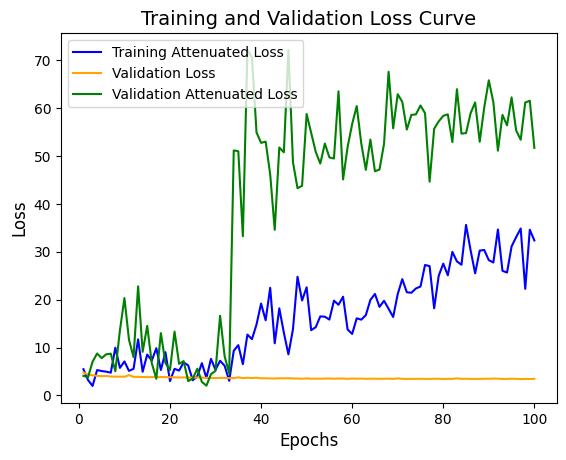

In [11]:
import matplotlib.pyplot as plt

# After training is finished, plot the loss curves
plt.plot(range(1, num_epochs+1), train_attenuated_losses, label='Training Attenuated Loss', color='blue')
plt.plot(range(1, num_epochs+1), val_losses, label='Validation Loss', color='orange')
plt.plot(range(1, num_epochs+1), val_attenuated_losses, label='Validation Attenuated Loss', color='green')
# Labeling x and y axes
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
# Adding title
plt.title('Training and Validation Loss Curve', fontsize=14)
# Adding legend
plt.legend()
# Show the plot
plt.show()